# PEA-STA Analysis

In [22]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt


In [23]:
def load_labels():
    cell_stage = np.array(pd.read_csv("./data/PEA_STA/cell_stage.csv", header=None))[0]
    labels = []
    for each in cell_stage:
        day = each.split("_")[1]
        treat = each.split("_")[2]
        if day == "0h":
            labels.append("0h untreated")
        elif day == "6d":
            if treat == "contol":
                labels.append("6d untreated")
            elif treat == "BMP4":
                labels.append("BMP4 treated")

    return labels

In [24]:
cell_embeddings = np.load('./mymodel_0.npy')
gene_embeddings = np.load('./mymodel_1.npy')
omics_embeddings = np.load('./mymodel_2.npy')

labels = load_labels()

In [25]:
cell_embeddings.shape, gene_embeddings.shape, omics_embeddings.shape

((210, 64), (166, 64), (2, 64))

## A. Cell Embeddings UMAP

Text(0, 0.5, 'UMAP_2')

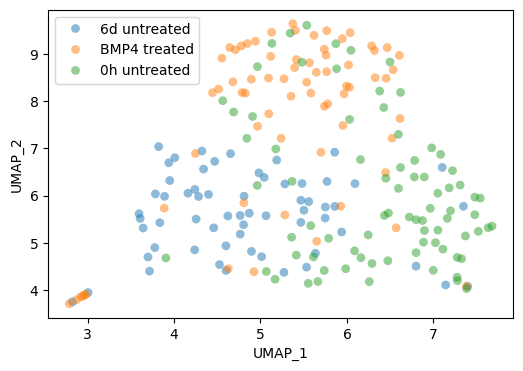

In [26]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=labels,
                s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


## Cell Clustering

In [27]:
from scoit.cell_analysis import cluster_evaluate

cluster_evaluate(cell_embeddings, labels)

{'NMI': 0.3333738955334327,
 'ARI': 0.29237729095799475,
 'FMI': 0.5465695036951725}